# Bangalore LULC Change Prediction: CA-ANN (After Amoah & Gorsevski 2025)
**Time periods:** 2005 → 2015 → 2025 → predict 2035 & 2045
**Driver variables:** Elevation, Slope, EucDist_PrimaryRoad, EucDist_secondaryRoads, EucDist_roadnetwork, EucDist_waterbody, EucDist_railwaySt, Distance_metro

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os, time
from pathlib import Path
from scipy.ndimage import generic_filter, uniform_filter
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import cohen_kappa_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import rasterio
from rasterio.plot import show
from rasterio.transform import from_bounds
import itertools

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── PATH CONFIG ── adjust if files are in a different folder
DATA_DIR = Path('.')  # assumes TIFs are in same folder as notebook

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [2]:
def load_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)
        meta = src.meta.copy()
        nodata = src.nodata
    return data, meta, nodata

def load_raster_masked(path):
    data, meta, nodata = load_raster(path)
    if nodata is not None:
        data[data == nodata] = np.nan
    return data, meta

# Load classified maps
lulc_2005, meta_2005, _ = load_raster(DATA_DIR / 'classified2005.tif')
lulc_2015, meta_2015, _ = load_raster(DATA_DIR / 'classified_2015.tif')
lulc_2025, meta_2025, _ = load_raster(DATA_DIR / 'classified2025.tif')

print('Raw LULC shapes:', lulc_2005.shape, lulc_2015.shape, lulc_2025.shape)

# ── FIX 1: Align all arrays to the minimum common shape ──────────────────────
# classified2005.tif is (2069, 2269) while drivers and other LULC files are
# (2068, 2268). Crop everything to the intersection so shapes broadcast cleanly.
min_rows = min(lulc_2005.shape[0], lulc_2015.shape[0], lulc_2025.shape[0])
min_cols = min(lulc_2005.shape[1], lulc_2015.shape[1], lulc_2025.shape[1])
lulc_2005 = lulc_2005[:min_rows, :min_cols]
lulc_2015 = lulc_2015[:min_rows, :min_cols]
lulc_2025 = lulc_2025[:min_rows, :min_cols]

# Use the driver-resolution meta (2068x2268) as the reference; update to be safe
meta = meta_2015.copy()
meta.update({'height': min_rows, 'width': min_cols})

# ── FIX 2: Mask out 255 (nodata sentinel) in lulc_2005 ───────────────────────
# classified2005.tif uses 255 as nodata but the file lacks a declared nodata
# value, so load_raster doesn't strip it. Left in place it poisons CLASS_MAP
# (auto-detection adds 'Class_255') and corrupts the ANN training.
LULC_NODATA = 255
lulc_2005[lulc_2005 == LULC_NODATA] = np.nan

print('Aligned LULC shapes:', lulc_2005.shape, lulc_2015.shape, lulc_2025.shape)
print('CRS:', meta['crs'])
print('Resolution:', meta['transform'].a, 'm/pixel')

# Unique classes (255 is now gone)
for yr, arr in [('2005', lulc_2005), ('2015', lulc_2015), ('2025', lulc_2025)]:
    vals = np.unique(arr[~np.isnan(arr)]).astype(int)
    print(f'  {yr} classes: {vals}')

Raw LULC shapes: (2069, 2269) (2068, 2268) (2068, 2268)
Aligned LULC shapes: (2068, 2268) (2068, 2268) (2068, 2268)
CRS: EPSG:32643
Resolution: 30.0 m/pixel
  2005 classes: [1 2 3 4]
  2015 classes: [1 2 3 4]
  2025 classes: [1 2 3 4]


In [3]:
# ── CLASS LABEL MAP ── adjust labels to match your classification scheme
CLASS_MAP = {
    1: 'Built-up',
    2: 'Vegetation',
    3: 'Water',
    4: 'Bare Land',
}

# Gather actual classes present across ALL three LULC maps (NaN already masked)
all_vals = set()
for arr in [lulc_2005, lulc_2015, lulc_2025]:
    all_vals.update(np.unique(arr[~np.isnan(arr)]).astype(int).tolist())

# Only auto-fill classes that are genuinely missing from CLASS_MAP
# (never auto-add values that look like nodata, e.g. 0 or 255)
NODATA_SENTINELS = {0, 255}
missing = all_vals - set(CLASS_MAP.keys()) - NODATA_SENTINELS
if missing:
    print(f'INFO: Adding unlabelled class IDs to CLASS_MAP: {sorted(missing)}')
    for c in sorted(missing):
        CLASS_MAP[c] = f'Class_{c}'

# Drop any stray nodata values that somehow survived
for bad in NODATA_SENTINELS:
    CLASS_MAP.pop(bad, None)

print('Class mapping:', CLASS_MAP)
N_CLASSES = len(CLASS_MAP)
CLASS_IDS  = sorted(CLASS_MAP.keys())

Class mapping: {1: 'Built-up', 2: 'Vegetation', 3: 'Water', 4: 'Bare Land'}


In [4]:
# Load driver variables
DRIVER_FILES = {
    'Elevation':          DATA_DIR / 'Elevation.tif',
    'Slope':              DATA_DIR / 'Slope.tif',
    'Dist_PrimaryRoad':   DATA_DIR / 'EucDist_PrimaryRoad.tif',
    'Dist_SecondaryRoad': DATA_DIR / 'EucDist_secondaryRoads.tif',
    'Dist_RoadNetwork':   DATA_DIR / 'EucDist_roadnetwork.tif',
    'Dist_Waterbody':     DATA_DIR / 'EucDist_waterbody.tif',
    'Dist_RailwayStation':DATA_DIR / 'EucDist_railwaySt.tif',
    'Dist_Metro':         DATA_DIR / 'Distance_metro.tif',
}

drivers = {}
for name, fpath in DRIVER_FILES.items():
    arr, _ = load_raster_masked(fpath)
    drivers[name] = arr
    print(f'  {name}: min={np.nanmin(arr):.2f}, max={np.nanmax(arr):.2f}, shape={arr.shape}')

  Elevation: min=649.00, max=1031.00, shape=(2068, 2268)
  Slope: min=0.00, max=71.17, shape=(2068, 2268)
  Dist_PrimaryRoad: min=0.00, max=11400.16, shape=(2068, 2268)
  Dist_SecondaryRoad: min=0.00, max=6831.84, shape=(2068, 2268)
  Dist_RoadNetwork: min=0.00, max=1758.01, shape=(2068, 2268)
  Dist_Waterbody: min=0.00, max=29209.37, shape=(2068, 2268)
  Dist_RailwayStation: min=0.00, max=25690.16, shape=(2068, 2268)
  Dist_Metro: min=0.00, max=32599.63, shape=(2068, 2268)


## 2. Preprocessing

In [5]:
rows, cols = lulc_2005.shape
PIXEL_AREA_HA = (abs(meta['transform'].a) * abs(meta['transform'].e)) / 10000  # m² → ha

def normalize_driver(arr):
    """MinMax normalize to [0,1], preserving NaN."""
    mn, mx = np.nanmin(arr), np.nanmax(arr)
    if mx == mn:
        return np.zeros_like(arr)
    out = (arr - mn) / (mx - mn)
    out[np.isnan(arr)] = np.nan
    return out.astype(np.float32)

drivers_norm = {k: normalize_driver(v) for k, v in drivers.items()}

# Build valid mask: pixels valid in ALL layers
valid_mask = np.ones((rows, cols), dtype=bool)
for arr in drivers_norm.values():
    valid_mask &= ~np.isnan(arr)
valid_mask &= ~np.isnan(lulc_2005)
valid_mask &= ~np.isnan(lulc_2015)
valid_mask &= ~np.isnan(lulc_2025)

print(f'Valid pixels: {valid_mask.sum():,} / {rows*cols:,}  ({valid_mask.mean()*100:.1f}%)')

# Convert LULC to int; mask invalid
def safe_int(arr, mask):
    out = arr.copy()
    out[~mask] = 0
    return out.astype(np.int16)

L05 = safe_int(lulc_2005, valid_mask)
L15 = safe_int(lulc_2015, valid_mask)
L25 = safe_int(lulc_2025, valid_mask)

Valid pixels: 4,690,224 / 4,690,224  (100.0%)


## 3. LULC Change Analysis

In [6]:
def area_stats(lulc, mask, class_map, pixel_ha):
    stats = {}
    total = mask.sum()
    for cid, cname in class_map.items():
        count = ((lulc == cid) & mask).sum()
        stats[cname] = {'pixels': count, 'ha': count * pixel_ha, 'pct': count / total * 100}
    return stats

stats_05 = area_stats(L05, valid_mask, CLASS_MAP, PIXEL_AREA_HA)
stats_15 = area_stats(L15, valid_mask, CLASS_MAP, PIXEL_AREA_HA)
stats_25 = area_stats(L25, valid_mask, CLASS_MAP, PIXEL_AREA_HA)

df_area = pd.DataFrame({
    '2005 (ha)': {k: v['ha'] for k,v in stats_05.items()},
    '2015 (ha)': {k: v['ha'] for k,v in stats_15.items()},
    '2025 (ha)': {k: v['ha'] for k,v in stats_25.items()},
    '2005 (%)':  {k: v['pct'] for k,v in stats_05.items()},
    '2015 (%)':  {k: v['pct'] for k,v in stats_15.items()},
    '2025 (%)':  {k: v['pct'] for k,v in stats_25.items()},
})
print(df_area.round(2).to_string())

            2005 (ha)  2015 (ha)  2025 (ha)  2005 (%)  2015 (%)  2025 (%)
Built-up     45113.22   58170.78  100881.09     10.69     13.78     23.90
Vegetation  176665.14  175291.38  164238.93     41.85     41.53     38.91
Water         2247.03    5020.92    6390.45      0.53      1.19      1.51
Bare Land   198094.77  183637.08  150609.69     46.93     43.50     35.68


In [7]:
def dynamic_degree(area_start, area_end, years):
    """Annual rate of change (%) per Eq. 3 in paper."""
    return (area_end - area_start) / (area_start * years) * 100

dd_05_15, dd_15_25, dd_05_25 = {}, {}, {}
for cls in CLASS_MAP.values():
    a05 = stats_05[cls]['ha']
    a15 = stats_15[cls]['ha']
    a25 = stats_25[cls]['ha']
    dd_05_15[cls] = dynamic_degree(a05, a15, 10)
    dd_15_25[cls] = dynamic_degree(a15, a25, 10)
    dd_05_25[cls] = dynamic_degree(a05, a25, 20)

df_change = pd.DataFrame({
    'Δ Area 05-15 (ha)': {cls: stats_15[cls]['ha'] - stats_05[cls]['ha'] for cls in CLASS_MAP.values()},
    'DD 05-15 (%/yr)':   dd_05_15,
    'Δ Area 15-25 (ha)': {cls: stats_25[cls]['ha'] - stats_15[cls]['ha'] for cls in CLASS_MAP.values()},
    'DD 15-25 (%/yr)':   dd_15_25,
    'Δ Area 05-25 (ha)': {cls: stats_25[cls]['ha'] - stats_05[cls]['ha'] for cls in CLASS_MAP.values()},
    'DD 05-25 (%/yr)':   dd_05_25,
})
print('\nLULC Change Statistics:')
print(df_change.round(3).to_string())


LULC Change Statistics:
            Δ Area 05-15 (ha)  DD 05-15 (%/yr)  Δ Area 15-25 (ha)  DD 15-25 (%/yr)  Δ Area 05-25 (ha)  DD 05-25 (%/yr)
Built-up             13057.56            2.894           42710.31            7.342           55767.87            6.181
Vegetation           -1373.76           -0.078          -11052.45           -0.631          -12426.21           -0.352
Water                 2773.89           12.345            1369.53            2.728            4143.42            9.220
Bare Land           -14457.69           -0.730          -33027.39           -1.799          -47485.08           -1.199


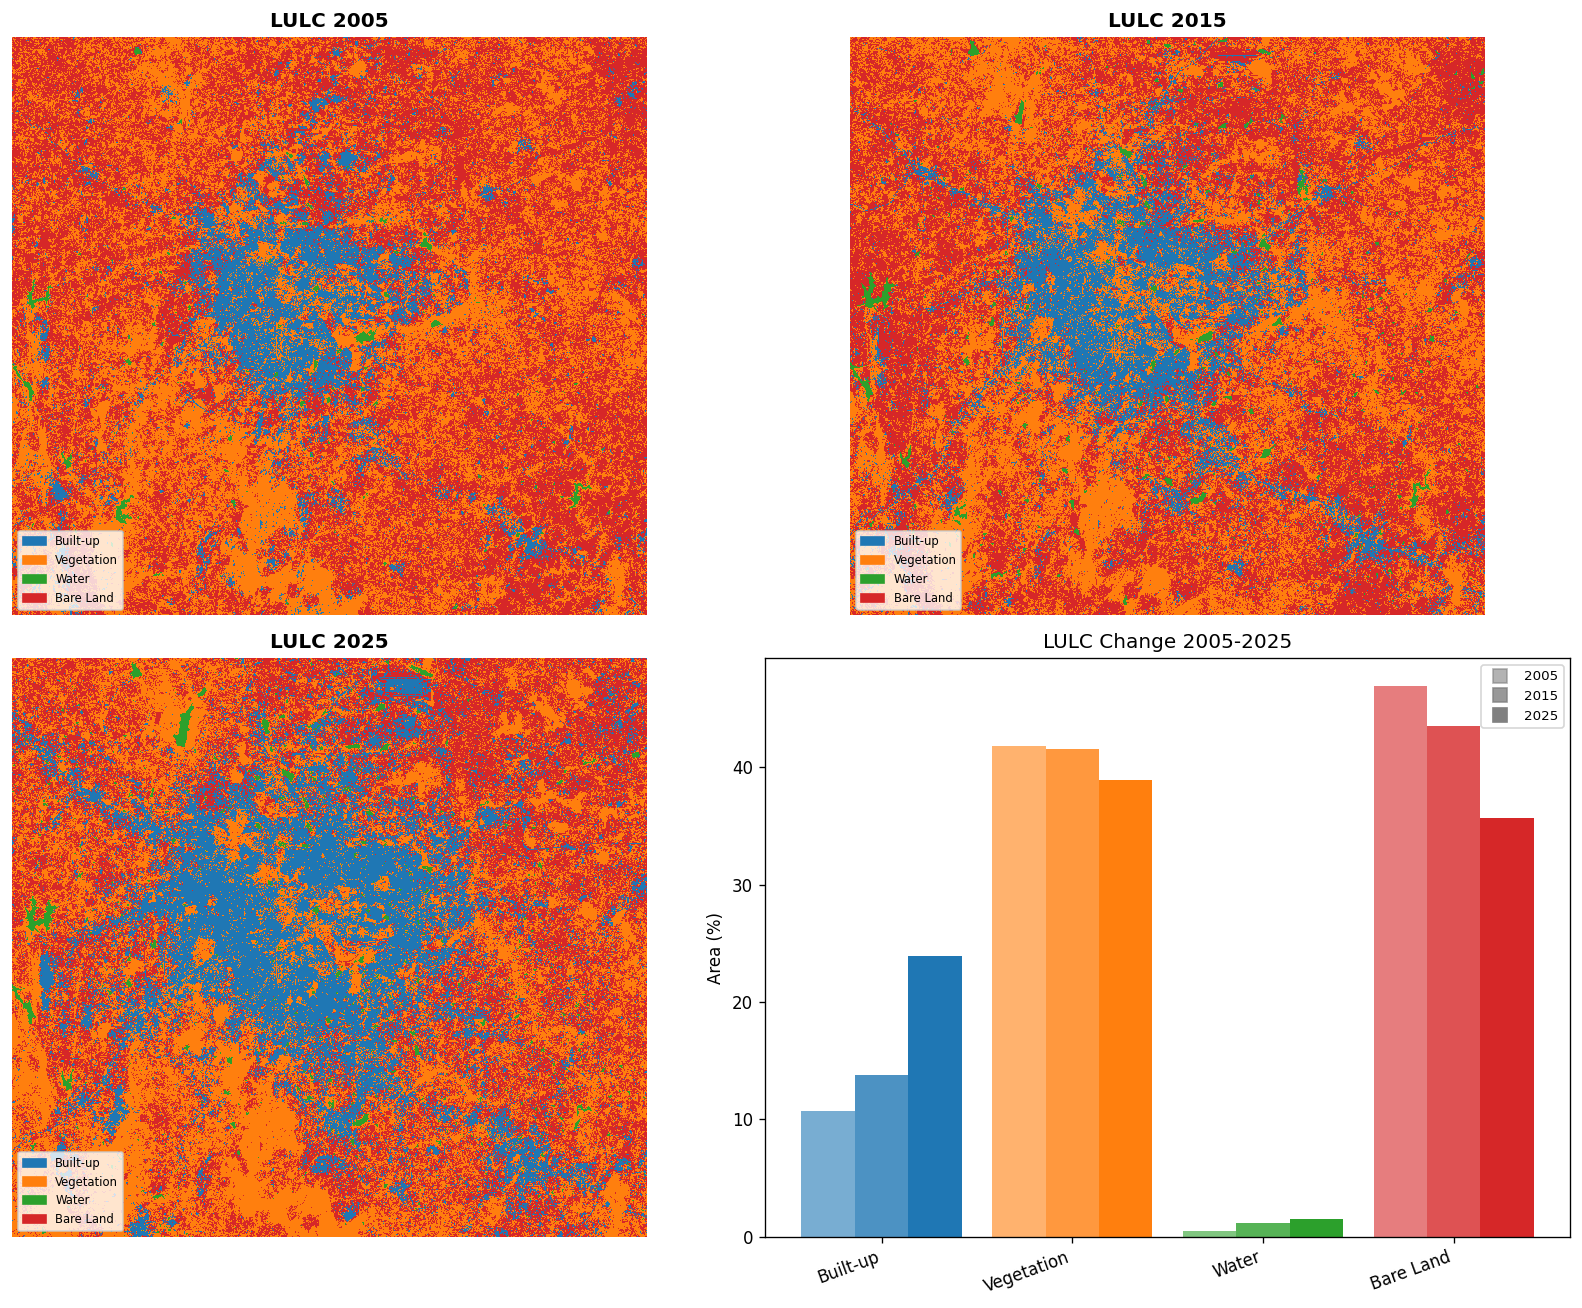

In [8]:
# Visualization: LULC Maps + Change Bar Chart
COLORS = plt.cm.tab10.colors
cmap = mcolors.ListedColormap([COLORS[i % 10] for i in range(N_CLASSES)])
bounds = CLASS_IDS + [max(CLASS_IDS)+1]
norm = mcolors.BoundaryNorm(bounds, cmap.N)
legend_patches = [Patch(color=COLORS[i], label=CLASS_MAP[c]) for i, c in enumerate(CLASS_IDS)]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, (lulc, yr) in zip(axes.flatten()[:3], [(L05,'2005'),(L15,'2015'),(L25,'2025')]):
    disp = lulc.astype(float)
    disp[~valid_mask] = np.nan
    im = ax.imshow(disp, cmap=cmap, norm=norm, interpolation='nearest')
    ax.set_title(f'LULC {yr}', fontweight='bold')
    ax.axis('off')
    ax.legend(handles=legend_patches, loc='lower left', fontsize=7, framealpha=0.8)

ax = axes[1][1]
x = np.arange(len(CLASS_MAP))
w = 0.28
pcts = [[stats_05[c]['pct'], stats_15[c]['pct'], stats_25[c]['pct']] for c in CLASS_MAP.values()]
for i, (pct, lbl) in enumerate(zip(pcts, CLASS_MAP.values())):
    ax.bar(x[i]-w, pct[0], w, color=COLORS[i], alpha=0.6, label=f'{lbl}-2005')
    ax.bar(x[i],   pct[1], w, color=COLORS[i], alpha=0.8)
    ax.bar(x[i]+w, pct[2], w, color=COLORS[i], alpha=1.0)
ax.set_xticks(x)
ax.set_xticklabels(list(CLASS_MAP.values()), rotation=20, ha='right')
ax.set_ylabel('Area (%)')
ax.set_title('LULC Change 2005-2025')
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0],color='gray',lw=0,marker='s',ms=8,alpha=a,label=yr)
                   for a,yr in [(0.6,'2005'),(0.8,'2015'),(1.0,'2025')]], fontsize=8)
plt.tight_layout()
plt.savefig('lulc_change_maps.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Transition Probability Matrix (Markov)

In [9]:
def transition_matrix(lulc_t1, lulc_t2, class_ids, mask):
    """Compute transition probability matrix."""
    n = len(class_ids)
    idx = {c: i for i, c in enumerate(class_ids)}
    counts = np.zeros((n, n), dtype=np.float64)
    m = mask & (lulc_t1 > 0) & (lulc_t2 > 0)
    for i, c1 in enumerate(class_ids):
        sub = lulc_t2[m & (lulc_t1 == c1)]
        for j, c2 in enumerate(class_ids):
            counts[i, j] = (sub == c2).sum()
    # Normalize rows
    row_sums = counts.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return counts / row_sums

T_05_15 = transition_matrix(L05, L15, CLASS_IDS, valid_mask)
T_15_25 = transition_matrix(L15, L25, CLASS_IDS, valid_mask)
T_05_25 = transition_matrix(L05, L25, CLASS_IDS, valid_mask)

labels = list(CLASS_MAP.values())
for T, period in [(T_05_15,'2005-2015'),(T_15_25,'2015-2025'),(T_05_25,'2005-2025')]:
    df = pd.DataFrame(T, index=labels, columns=labels)
    print(f'\nTransition Matrix {period}:')
    print(df.round(3).to_string())


Transition Matrix 2005-2015:
            Built-up  Vegetation  Water  Bare Land
Built-up       0.650       0.120  0.010      0.221
Vegetation     0.054       0.685  0.009      0.252
Water          0.019       0.192  0.756      0.033
Bare Land      0.098       0.244  0.006      0.652

Transition Matrix 2015-2025:
            Built-up  Vegetation  Water  Bare Land
Built-up       0.752       0.118  0.010      0.120
Vegetation     0.103       0.630  0.009      0.259
Water          0.029       0.282  0.596      0.093
Bare Land      0.212       0.248  0.007      0.533

Transition Matrix 2005-2025:
            Built-up  Vegetation  Water  Bare Land
Built-up       0.724       0.134  0.015      0.127
Vegetation     0.137       0.576  0.014      0.273
Water          0.025       0.349  0.593      0.033
Bare Land      0.222       0.281  0.010      0.487


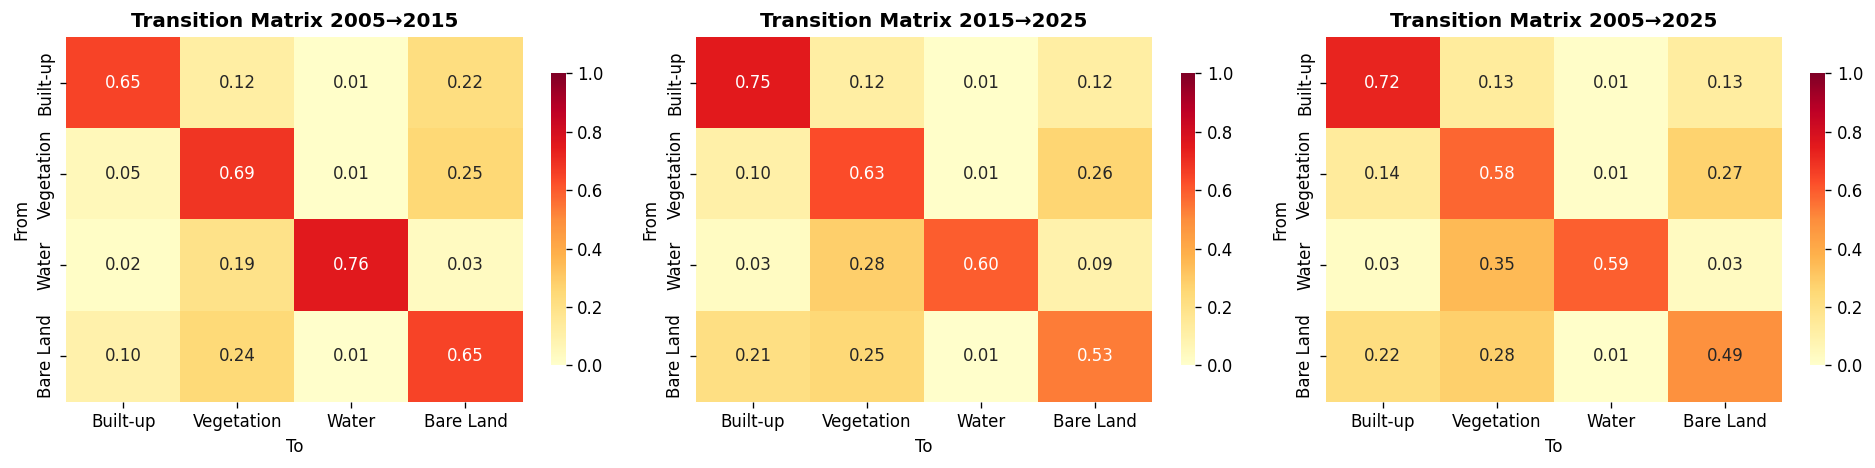

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (T, period) in zip(axes, [(T_05_15,'2005→2015'),(T_15_25,'2015→2025'),(T_05_25,'2005→2025')]):
    sns.heatmap(T, annot=True, fmt='.2f', xticklabels=labels, yticklabels=labels,
                cmap='YlOrRd', ax=ax, vmin=0, vmax=1, cbar_kws={'shrink':0.8})
    ax.set_title(f'Transition Matrix {period}', fontweight='bold')
    ax.set_xlabel('To')
    ax.set_ylabel('From')
plt.tight_layout()
plt.savefig('transition_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Driver Variable Analysis (Pearson Correlation)

Pearson correlation with LULC change:
Dist_PrimaryRoad      -0.0876
Dist_SecondaryRoad    -0.0850
Dist_RoadNetwork      -0.0706
Dist_Waterbody        -0.0664
Slope                 -0.0584
Dist_RailwayStation   -0.0565
Dist_Metro            -0.0537
Elevation              0.0514


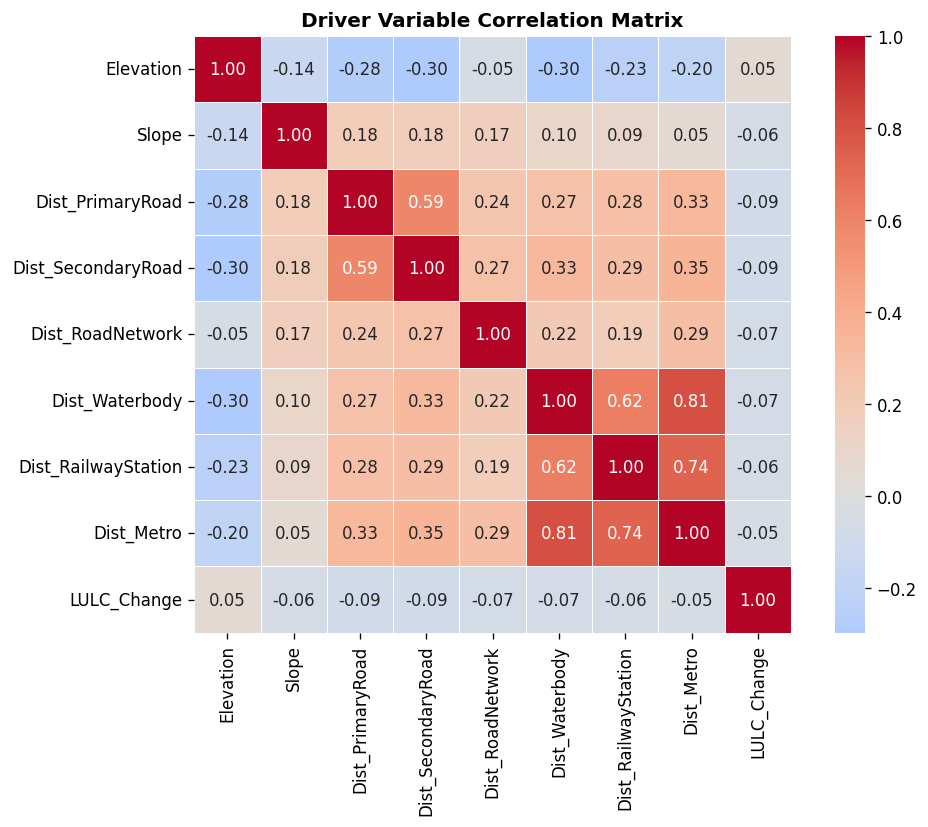

In [11]:
# Sample for correlation (use valid pixels only)
idx_valid = np.where(valid_mask.ravel())[0]
# Subsample up to 100k pixels for speed
rng = np.random.default_rng(42)
if len(idx_valid) > 100_000:
    idx_sample = rng.choice(idx_valid, size=100_000, replace=False)
else:
    idx_sample = idx_valid

driver_matrix = np.column_stack([v.ravel()[idx_sample] for v in drivers_norm.values()])
lulc_change_vec = (L25.ravel()[idx_sample] != L05.ravel()[idx_sample]).astype(float)  # binary change

corr_df = pd.DataFrame(driver_matrix, columns=list(drivers_norm.keys()))
corr_df['LULC_Change'] = lulc_change_vec

corr = corr_df.corr()
print('Pearson correlation with LULC change:')
print(corr['LULC_Change'].drop('LULC_Change').sort_values(key=abs, ascending=False).round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, center=0,
            square=True, linewidths=0.5)
ax.set_title('Driver Variable Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('driver_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. ANN Transition Potential Model

In [12]:
def build_features(lulc_t1, drivers_norm, mask, neighborhood=True, patch_size=3):
    """
    Build feature matrix for ANN:
    - Normalized driver variables
    - 3x3 neighborhood context from lulc_t1 (spatial autocorrelation)
    """
    r, c = lulc_t1.shape
    feats = [v.ravel() for v in drivers_norm.values()]
    
    if neighborhood:
        # One-hot neighborhood proportions for each class
        for cid in CLASS_IDS:
            binary = (lulc_t1 == cid).astype(np.float32)
            # proportion of class in 3x3 window
            prop = uniform_filter(binary, size=patch_size, mode='constant')
            feats.append(prop.ravel())
    
    X = np.column_stack(feats)  # shape: (pixels, n_features)
    valid_idx = np.where(mask.ravel())[0]
    return X, valid_idx

print('Building features for 2005→2015 training...')
X_full, valid_idx = build_features(L05, drivers_norm, valid_mask)
y_full = L15.ravel()  # target: 2015 LULC

X_valid = X_full[valid_idx]
y_valid = y_full[valid_idx]

# Remove samples with class 0 (masked)
keep = y_valid > 0
X_valid = X_valid[keep]
y_valid = y_valid[keep]
valid_idx_keep = valid_idx[keep]

print(f'Training samples: {len(X_valid):,}')
print(f'Features: {X_valid.shape[1]}')
print(f'Class distribution: {dict(zip(*np.unique(y_valid, return_counts=True)))}')

Building features for 2005→2015 training...
Training samples: 4,690,224
Features: 12
Class distribution: {np.int16(1): np.int64(646342), np.int16(2): np.int64(1947682), np.int16(3): np.int64(55788), np.int16(4): np.int64(2040412)}


In [13]:
# Stratified subsample for training (balance classes, speed)
SAMPLES_PER_CLASS = 5000
rng = np.random.default_rng(42)

train_idx_list = []
for cid in CLASS_IDS:
    cls_idx = np.where(y_valid == cid)[0]
    if len(cls_idx) == 0:
        continue
    n = min(SAMPLES_PER_CLASS, len(cls_idx))
    train_idx_list.append(rng.choice(cls_idx, size=n, replace=False))

train_idx = np.concatenate(train_idx_list)
rng.shuffle(train_idx)

X_train = X_valid[train_idx]
y_train = y_valid[train_idx]
print(f'Balanced training samples: {len(X_train):,}')
print(f'Class dist: {dict(zip(*np.unique(y_train, return_counts=True)))}')

Balanced training samples: 20,000
Class dist: {np.int16(1): np.int64(5000), np.int16(2): np.int64(5000), np.int16(3): np.int64(5000), np.int16(4): np.int64(5000)}


In [14]:
# Fit scaler on training data
scaler = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train)
X_valid_sc  = scaler.transform(X_valid)

# Class weights for imbalanced classes
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight = dict(zip(np.unique(y_train), cw))

# ANN — mirroring paper: 5 hidden layers, learning_rate=0.005, momentum=0.07
# MLPClassifier uses adam/sgd; we replicate spirit with comparable architecture
ann = MLPClassifier(
    hidden_layer_sizes=(128, 128, 64, 64, 32),  # 5 hidden layers
    activation='relu',
    solver='adam',
    learning_rate_init=0.005,
    momentum=0.07,          # used when solver='sgd'
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
    verbose=True,
)

print('Training ANN...')
t0 = time.time()
ann.fit(X_train_sc, y_train)
print(f'Done in {time.time()-t0:.1f}s | Iterations: {ann.n_iter_}')

Training ANN...
Iteration 1, loss = 0.94895238
Validation score: 0.622500
Iteration 2, loss = 0.86643332
Validation score: 0.628000
Iteration 3, loss = 0.84537965
Validation score: 0.649500
Iteration 4, loss = 0.82887608
Validation score: 0.643000
Iteration 5, loss = 0.80481976
Validation score: 0.644500
Iteration 6, loss = 0.79643959
Validation score: 0.657000
Iteration 7, loss = 0.78692722
Validation score: 0.654500
Iteration 8, loss = 0.77832037
Validation score: 0.658000
Iteration 9, loss = 0.76981437
Validation score: 0.660500
Iteration 10, loss = 0.77302390
Validation score: 0.654500
Iteration 11, loss = 0.76276970
Validation score: 0.664500
Iteration 12, loss = 0.75389481
Validation score: 0.679500
Iteration 13, loss = 0.74754167
Validation score: 0.674000
Iteration 14, loss = 0.74316645
Validation score: 0.676000
Iteration 15, loss = 0.73863417
Validation score: 0.669500
Iteration 16, loss = 0.73537397
Validation score: 0.682500
Iteration 17, loss = 0.72860748
Validation score:

In [15]:
# 5-fold cross-validation kappa on training data
print('Running 5-fold cross-validation...')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

kappas = []
for fold, (tr, te) in enumerate(skf.split(X_train_sc, y_train)):
    ann_tmp = MLPClassifier(
        hidden_layer_sizes=(128, 128, 64, 64, 32),
        activation='relu', solver='adam',
        learning_rate_init=0.005, max_iter=300,
        random_state=42
    )
    ann_tmp.fit(X_train_sc[tr], y_train[tr])
    pred = ann_tmp.predict(X_train_sc[te])
    k = cohen_kappa_score(y_train[te], pred)
    kappas.append(k)
    print(f'  Fold {fold+1}: kappa={k:.4f}')

print(f'Mean CV Kappa: {np.mean(kappas):.4f} ± {np.std(kappas):.4f}')

Running 5-fold cross-validation...
  Fold 1: kappa=0.5633
  Fold 2: kappa=0.5477
  Fold 3: kappa=0.5603
  Fold 4: kappa=0.5487
  Fold 5: kappa=0.5480
Mean CV Kappa: 0.5536 ± 0.0068


## 7. CA-ANN Simulation (2005→2015 for calibration)

In [16]:
def predict_transition_potential(ann, scaler, drivers_norm, lulc_current, mask, batch_size=50000):
    """Predict class probabilities for every valid pixel."""
    X_full, valid_idx = build_features(lulc_current, drivers_norm, mask)
    X_val = X_full[valid_idx]
    X_val_sc = scaler.transform(X_val)
    
    # Batch prediction to avoid memory issues
    proba_list = []
    for i in range(0, len(X_val_sc), batch_size):
        proba_list.append(ann.predict_proba(X_val_sc[i:i+batch_size]))
    proba = np.vstack(proba_list)  # (valid_pixels, n_classes)
    
    # Full map probabilities
    full_proba = np.zeros((lulc_current.size, len(ann.classes_)), dtype=np.float32)
    full_proba[valid_idx] = proba
    return full_proba.reshape(lulc_current.shape[0], lulc_current.shape[1], -1)  # (H, W, C)


def markov_demand(lulc_t1, trans_matrix, class_ids, mask, target_year_steps):
    """Compute expected area of each class at future time using Markov chain."""
    n = len(class_ids)
    # Raise transition matrix to power of time steps
    T_power = np.linalg.matrix_power(trans_matrix, target_year_steps)
    
    current_areas = np.array([(lulc_t1[mask] == cid).sum() for cid in class_ids], dtype=float)
    future_areas = current_areas @ T_power
    return {cid: int(future_areas[i]) for i, cid in enumerate(class_ids)}


def ca_ann_simulate(lulc_current, trans_proba, drivers_norm, ann, scaler,
                    trans_matrix, class_ids, mask, n_steps=10, random_seed=42):
    """
    CA-ANN simulation:
    1. Compute transition potential via ANN (spatial suitability)
    2. Use Markov demand to determine how many pixels should transition
    3. Allocate changes to highest-suitability pixels
    
    n_steps: number of 1-year CA iterations
    """
    rng = np.random.default_rng(random_seed)
    lulc_sim = lulc_current.copy()
    
    # Overall demand from Markov
    demand = markov_demand(lulc_current, trans_matrix, class_ids, mask, n_steps)
    print(f'Markov demand for {n_steps}-step projection:')
    for cid in class_ids:
        print(f'  {CLASS_MAP[cid]}: {demand[cid]:,} pixels')
    
    # Run CA iteration-by-iteration (1 step = 1 year)
    for step in range(n_steps):
        # ANN: get transition probabilities for current state
        pot = predict_transition_potential(ann, scaler, drivers_norm, lulc_sim, mask)
        # pot shape: (H, W, n_classes)
        
        # For each class, determine how many pixels should become that class
        current_counts = {cid: (lulc_sim[mask] == cid).sum() for cid in class_ids}
        target_counts  = markov_demand(lulc_sim, trans_matrix, class_ids, mask, 1)
        
        new_lulc = lulc_sim.copy()
        
        # Process each target class in order of most change
        change_needed = {cid: target_counts[cid] - current_counts[cid] for cid in class_ids}
        # Sort by most gain first
        for cid in sorted(class_ids, key=lambda c: -change_needed[c]):
            needed = change_needed[cid]
            if needed <= 0:
                continue
            cidx = ann.classes_.tolist().index(cid) if cid in ann.classes_ else None
            if cidx is None:
                continue
            
            # Suitability map for this class
            suit = pot[:, :, cidx].copy()
            # Only consider pixels NOT already this class
            suit[lulc_sim == cid] = -1
            suit[~mask] = -1
            
            # Add small random perturbation (stochastic CA)
            suit[mask] += rng.uniform(0, 0.05, size=mask.sum())
            
            # Select top-N pixels
            flat_suit = suit.ravel()
            n_change = min(needed, (flat_suit > 0).sum())
            if n_change <= 0:
                continue
            top_idx = np.argpartition(flat_suit, -n_change)[-n_change:]
            new_lulc.ravel()[top_idx] = cid
        
        lulc_sim = new_lulc
        if (step + 1) % 5 == 0 or step == 0:
            print(f'  CA step {step+1}/{n_steps} done')
    
    return lulc_sim

print('Functions defined.')

Functions defined.


In [17]:
# CALIBRATION: Simulate 2015 using 2005 data + 2005-2015 transition matrix
print('=== CALIBRATION: Simulating 2015 from 2005 ===')
L15_sim = ca_ann_simulate(
    lulc_current=L05,
    trans_proba=None,
    drivers_norm=drivers_norm,
    ann=ann,
    scaler=scaler,
    trans_matrix=T_05_15,
    class_ids=CLASS_IDS,
    mask=valid_mask,
    n_steps=10,
    random_seed=42
)
print('Calibration simulation complete.')

=== CALIBRATION: Simulating 2015 from 2005 ===
Markov demand for 10-step projection:
  Built-up: 815,301 pixels
  Vegetation: 1,855,486 pixels
  Water: 143,819 pixels
  Bare Land: 1,875,616 pixels
  CA step 1/10 done
  CA step 5/10 done
  CA step 10/10 done
Calibration simulation complete.


## 8. Validation Against 2015 (Quantity & Allocation Disagreement)

In [18]:
def pontius_millones_accuracy(reference, simulated, class_ids, mask):
    """
    Quantity disagreement (qg) and Allocation disagreement (ag)
    per Pontius & Millones 2011 — Eq. 1 & 2 in paper.
    """
    ref = reference[mask].ravel()
    sim = simulated[mask].ravel()
    keep = (ref > 0) & (sim > 0)
    ref, sim = ref[keep], sim[keep]
    n = len(ref)
    
    results = {}
    total_qd = 0
    total_ad = 0
    
    for g in class_ids:
        # Proportions in reference and simulated
        p_ref_g = (ref == g).sum() / n  # sum of p_ig over i = proportion of g in reference
        p_sim_g = (sim == g).sum() / n  # proportion of g in simulated
        p_gg    = ((ref == g) & (sim == g)).sum() / n  # correct pixels
        
        qg = abs(p_ref_g - p_sim_g)
        omission   = p_ref_g - p_gg   # missed pixels of g
        commission = p_sim_g - p_gg   # incorrectly assigned as g
        ag = 2 * min(omission, commission)
        
        results[CLASS_MAP[g]] = {'Quantity Disagreement': qg*100,
                                  'Allocation Disagreement': ag*100,
                                  'Total Disagreement': (qg+ag)*100}
        total_qd += qg
        total_ad += ag
    
    overall_agree = (ref == sim).sum() / n * 100
    kappa = cohen_kappa_score(ref, sim)
    
    return results, overall_agree, kappa, total_qd*100, total_ad*100


pm_results, oa, kappa, total_qd, total_ad = pontius_millones_accuracy(L15, L15_sim, CLASS_IDS, valid_mask)

print(f'\nCALIBRATION VALIDATION (Simulated 2015 vs Observed 2015):')
print(f'Overall Agreement : {oa:.2f}%')
print(f'Kappa             : {kappa:.4f}')
print(f'Total Qty Disagree: {total_qd:.2f}%')
print(f'Total Alloc Disagree: {total_ad:.2f}%')
print()
print(pd.DataFrame(pm_results).T.round(3).to_string())


CALIBRATION VALIDATION (Simulated 2015 vs Observed 2015):
Overall Agreement : 65.67%
Kappa             : 0.4613
Total Qty Disagree: 10.86%
Total Alloc Disagree: 57.79%

            Quantity Disagreement  Allocation Disagreement  Total Disagreement
Built-up                    3.557                    8.156              11.713
Vegetation                  2.043                   24.037              26.080
Water                       1.874                    0.630               2.504
Bare Land                   3.388                   24.971              28.359


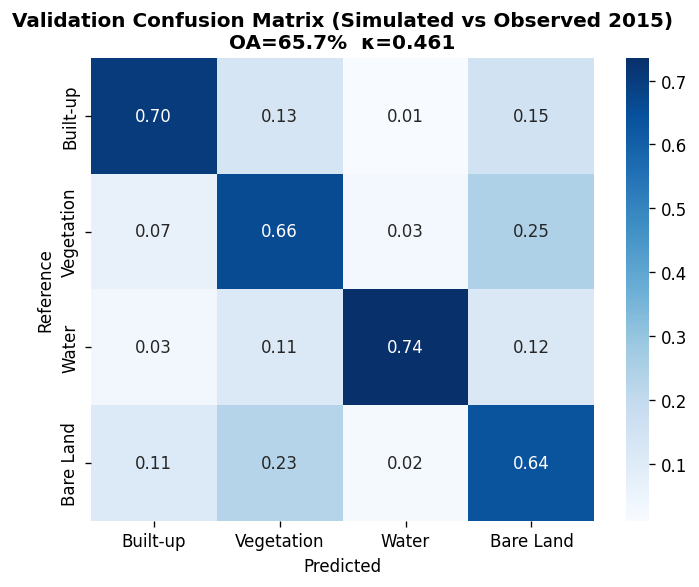

              precision    recall  f1-score   support

    Built-up       0.56      0.70      0.62    646342
  Vegetation       0.70      0.66      0.68   1947682
       Water       0.29      0.74      0.41     55788
   Bare Land       0.69      0.64      0.66   2040412

    accuracy                           0.66   4690224
   macro avg       0.56      0.68      0.59   4690224
weighted avg       0.67      0.66      0.66   4690224



In [19]:
# Confusion matrix heatmap
ref_flat = L15[valid_mask].ravel()
sim_flat = L15_sim[valid_mask].ravel()
keep = (ref_flat > 0) & (sim_flat > 0)

cm = confusion_matrix(ref_flat[keep], sim_flat[keep], labels=CLASS_IDS, normalize='true')
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='.2f', xticklabels=labels, yticklabels=labels,
            cmap='Blues', ax=ax)
ax.set_title(f'Validation Confusion Matrix (Simulated vs Observed 2015)\nOA={oa:.1f}%  κ={kappa:.3f}', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Reference')
plt.tight_layout()
plt.savefig('validation_confusion_2015.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(ref_flat[keep], sim_flat[keep], labels=CLASS_IDS,
                             target_names=labels, zero_division=0))

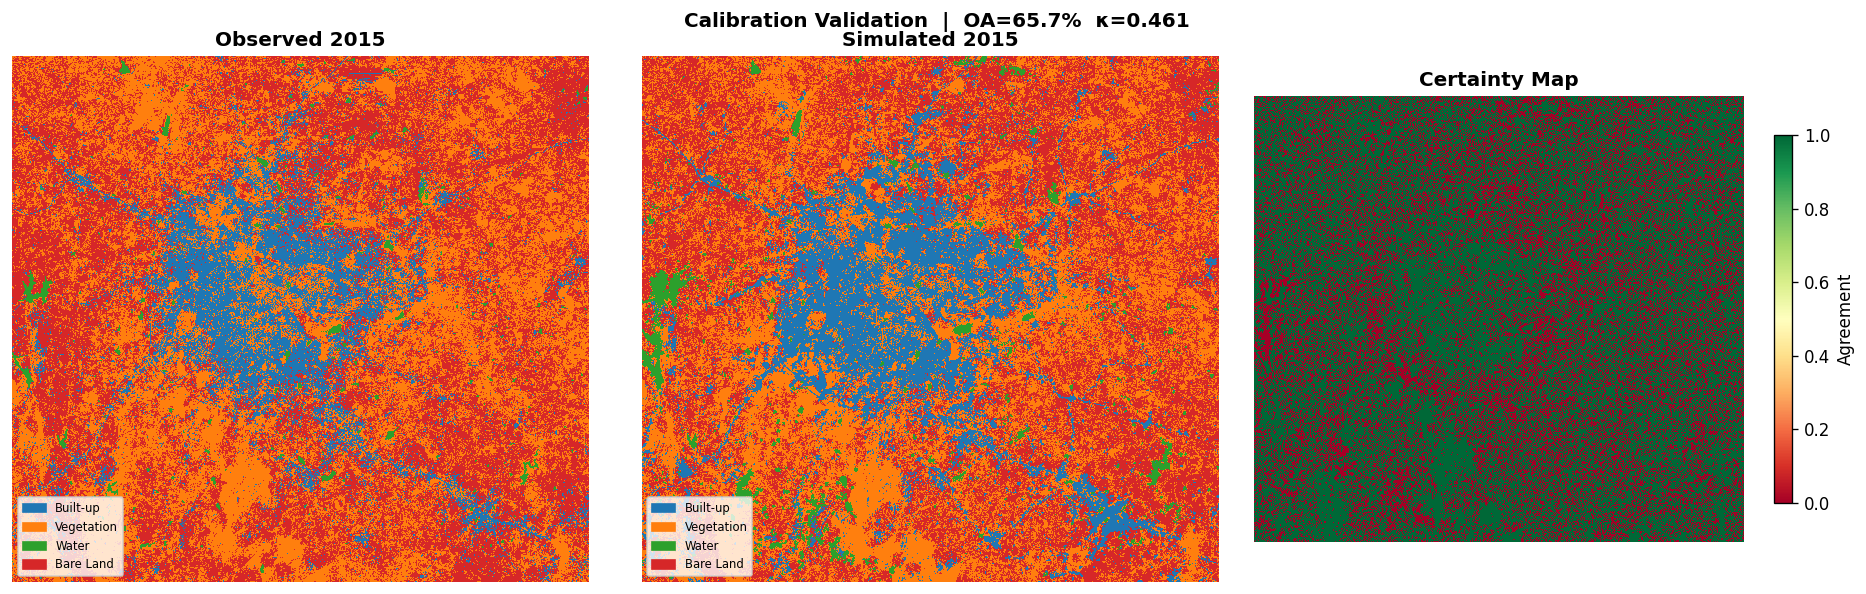

In [20]:
# Side-by-side: Observed 2015 vs Simulated 2015
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (arr, title) in zip(axes, [(L15,'Observed 2015'),(L15_sim,'Simulated 2015'),
                                     (None,'Certainty Map')]):
    if arr is not None:
        disp = arr.astype(float)
        disp[~valid_mask] = np.nan
        ax.imshow(disp, cmap=cmap, norm=norm, interpolation='nearest')
        ax.legend(handles=legend_patches, loc='lower left', fontsize=7)
    else:
        # Certainty: 1 where reference==simulated, 0 where different
        cert = (L15 == L15_sim).astype(float)
        cert[~valid_mask] = np.nan
        im = ax.imshow(cert, cmap='RdYlGn', vmin=0, vmax=1, interpolation='nearest')
        plt.colorbar(im, ax=ax, shrink=0.7, label='Agreement')
    ax.set_title(title, fontweight='bold')
    ax.axis('off')

plt.suptitle(f'Calibration Validation  |  OA={oa:.1f}%  κ={kappa:.3f}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('validation_comparison_2015.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Retrain ANN on Full 2005–2025 Data, Then Predict 2035 & 2045

In [21]:
# Retrain using 2015 as input → 2025 as target (most recent period captures latest dynamics)
print('Building features for 2015→2025 (final model training)...')
X_full2, valid_idx2 = build_features(L15, drivers_norm, valid_mask)
y_full2 = L25.ravel()
X_valid2 = X_full2[valid_idx2]
y_valid2 = y_full2[valid_idx2]
keep2 = y_valid2 > 0
X_valid2 = X_valid2[keep2]
y_valid2 = y_valid2[keep2]

# Balanced sample
train_idx_list2 = []
for cid in CLASS_IDS:
    cls_idx = np.where(y_valid2 == cid)[0]
    if len(cls_idx) == 0:
        continue
    n = min(SAMPLES_PER_CLASS, len(cls_idx))
    train_idx_list2.append(rng.choice(cls_idx, size=n, replace=False))
train_idx2 = np.concatenate(train_idx_list2)
rng.shuffle(train_idx2)

X_tr2 = X_valid2[train_idx2]
y_tr2 = y_valid2[train_idx2]

scaler2 = MinMaxScaler()
X_tr2_sc = scaler2.fit_transform(X_tr2)

ann2 = MLPClassifier(
    hidden_layer_sizes=(128, 128, 64, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.005,
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
    verbose=False,
)

print('Training final ANN on 2015→2025...')
t0 = time.time()
ann2.fit(X_tr2_sc, y_tr2)
print(f'Done in {time.time()-t0:.1f}s | Iters: {ann2.n_iter_}')

Building features for 2015→2025 (final model training)...
Training final ANN on 2015→2025...
Done in 40.6s | Iters: 76


In [22]:
# PROJECT 2035 (10 steps from 2025)
print('=== PROJECTING 2035 ===')
L35_sim = ca_ann_simulate(
    lulc_current=L25,
    trans_proba=None,
    drivers_norm=drivers_norm,
    ann=ann2,
    scaler=scaler2,
    trans_matrix=T_15_25,
    class_ids=CLASS_IDS,
    mask=valid_mask,
    n_steps=10,
    random_seed=42
)

# PROJECT 2045 (10 steps from 2035)
# Retrain ANN using 2025→2035 (simulated) for better 2045 projection
print('\n=== PROJECTING 2045 ===')
L45_sim = ca_ann_simulate(
    lulc_current=L35_sim,
    trans_proba=None,
    drivers_norm=drivers_norm,
    ann=ann2,
    scaler=scaler2,
    trans_matrix=T_15_25,  # use most recent trend
    class_ids=CLASS_IDS,
    mask=valid_mask,
    n_steps=10,
    random_seed=42
)
print('Projections complete.')

=== PROJECTING 2035 ===
Markov demand for 10-step projection:
  Built-up: 1,758,779 pixels
  Vegetation: 1,518,117 pixels
  Water: 100,284 pixels
  Bare Land: 1,313,042 pixels
  CA step 1/10 done
  CA step 5/10 done
  CA step 10/10 done

=== PROJECTING 2045 ===
Markov demand for 10-step projection:
  Built-up: 1,761,985 pixels
  Vegetation: 1,516,167 pixels
  Water: 100,566 pixels
  Bare Land: 1,311,503 pixels
  CA step 1/10 done
  CA step 5/10 done
  CA step 10/10 done
Projections complete.


## 10. Future Projections Analysis

In [23]:
stats_35 = area_stats(L35_sim, valid_mask, CLASS_MAP, PIXEL_AREA_HA)
stats_45 = area_stats(L45_sim, valid_mask, CLASS_MAP, PIXEL_AREA_HA)

df_future = pd.DataFrame({
    '2025 (ha)': {k: v['ha'] for k,v in stats_25.items()},
    '2035 sim (ha)': {k: v['ha'] for k,v in stats_35.items()},
    '2045 sim (ha)': {k: v['ha'] for k,v in stats_45.items()},
    '2025 (%)': {k: v['pct'] for k,v in stats_25.items()},
    '2035 sim (%)': {k: v['pct'] for k,v in stats_35.items()},
    '2045 sim (%)': {k: v['pct'] for k,v in stats_45.items()},
})
print('Future Projection Statistics:')
print(df_future.round(2).to_string())

dd_25_35, dd_35_45, dd_25_45 = {}, {}, {}
for cls in CLASS_MAP.values():
    a25 = stats_25[cls]['ha']
    a35 = stats_35[cls]['ha']
    a45 = stats_45[cls]['ha']
    dd_25_35[cls] = dynamic_degree(a25, a35, 10)
    dd_35_45[cls] = dynamic_degree(a35, a45, 10)
    dd_25_45[cls] = dynamic_degree(a25, a45, 20)

df_dd_future = pd.DataFrame({'DD 25-35 (%/yr)': dd_25_35,
                               'DD 35-45 (%/yr)': dd_35_45,
                               'DD 25-45 (%/yr)': dd_25_45})
print('\nAnnual Rate of Change (Dynamic Degree):')
print(df_dd_future.round(3).to_string())

Future Projection Statistics:
            2025 (ha)  2035 sim (ha)  2045 sim (ha)  2025 (%)  2035 sim (%)  2045 sim (%)
Built-up    100881.09      157019.76      158386.14     23.90         37.20         37.52
Vegetation  164238.93      138395.70      136699.92     38.91         32.79         32.38
Water         6390.45        9006.12        9049.86      1.51          2.13          2.14
Bare Land   150609.69      117698.58      117984.24     35.68         27.88         27.95

Annual Rate of Change (Dynamic Degree):
            DD 25-35 (%/yr)  DD 35-45 (%/yr)  DD 25-45 (%/yr)
Built-up              5.565            0.087            2.850
Vegetation           -1.574           -0.123           -0.838
Water                 4.093            0.049            2.081
Bare Land            -2.185            0.024           -1.083


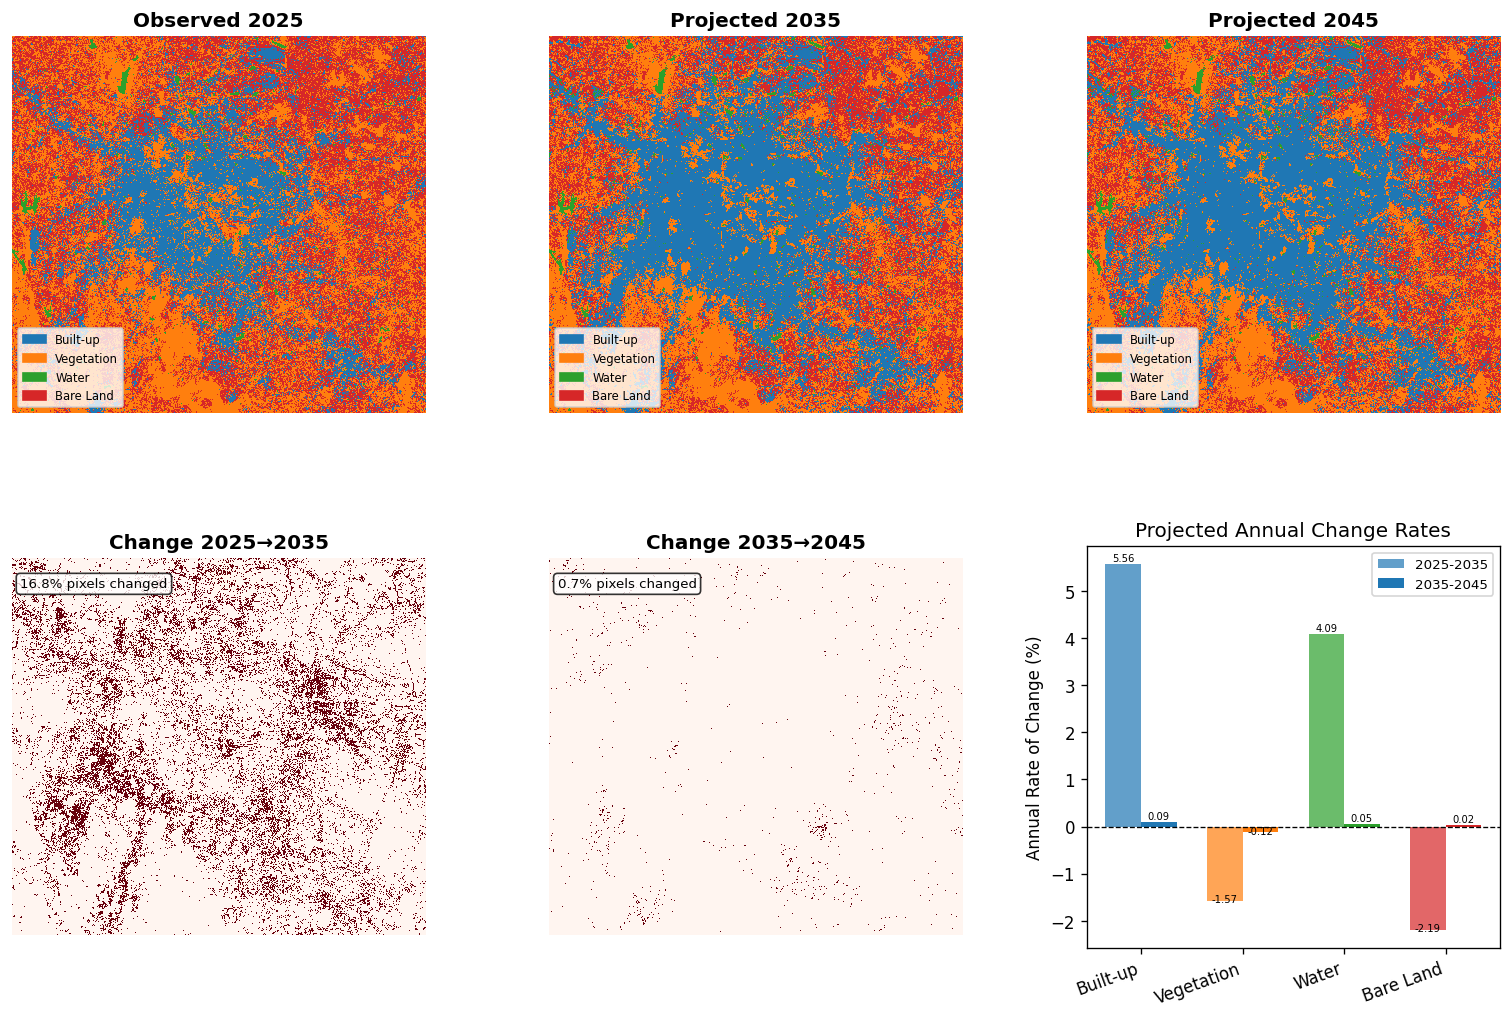

In [24]:
# Projected LULC maps + rate of change chart
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

for idx, (arr, title) in enumerate([
        (L25, 'Observed 2025'), (L35_sim, 'Projected 2035'), (L45_sim, 'Projected 2045')]):
    ax = fig.add_subplot(gs[0, idx])
    disp = arr.astype(float); disp[~valid_mask] = np.nan
    ax.imshow(disp, cmap=cmap, norm=norm, interpolation='nearest')
    ax.set_title(title, fontweight='bold')
    ax.axis('off')
    ax.legend(handles=legend_patches, loc='lower left', fontsize=7, framealpha=0.8)

# Change maps
for idx, (base, proj, title) in enumerate([
        (L25, L35_sim, 'Change 2025→2035'), (L35_sim, L45_sim, 'Change 2035→2045')]):
    ax = fig.add_subplot(gs[1, idx])
    change = np.zeros_like(base, dtype=float)
    change[valid_mask & (base != proj)] = 1
    change[~valid_mask] = np.nan
    im = ax.imshow(change, cmap='Reds', vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(title, fontweight='bold')
    ax.axis('off')
    pct_change = change[valid_mask].mean() * 100
    ax.text(0.02, 0.95, f'{pct_change:.1f}% pixels changed',
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Rate of change bar chart
ax = fig.add_subplot(gs[1, 2])
x = np.arange(N_CLASSES)
w = 0.35
bars1 = ax.bar(x - w/2, [dd_25_35[c] for c in CLASS_MAP.values()], w,
               color=[COLORS[i] for i in range(N_CLASSES)], alpha=0.7, label='2025-2035')
bars2 = ax.bar(x + w/2, [dd_35_45[c] for c in CLASS_MAP.values()], w,
               color=[COLORS[i] for i in range(N_CLASSES)], alpha=1.0, label='2035-2045')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(list(CLASS_MAP.values()), rotation=20, ha='right')
ax.set_ylabel('Annual Rate of Change (%)')
ax.set_title('Projected Annual Change Rates')
ax.legend(fontsize=8)
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + (0.02 if h >= 0 else -0.08),
            f'{h:.2f}', ha='center', va='bottom', fontsize=6)

plt.savefig('projected_lulc_2035_2045.png', dpi=150, bbox_inches='tight')
plt.show()

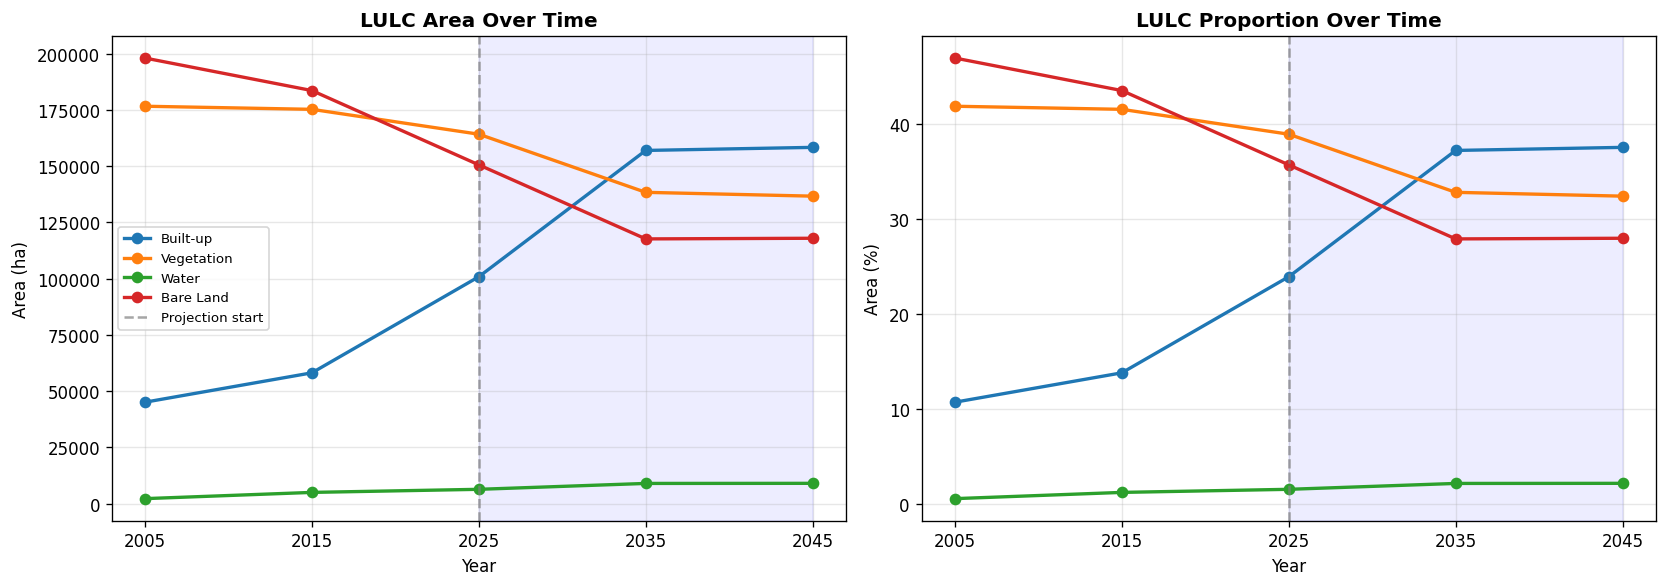

In [25]:
# Full area timeline: 2005 → 2015 → 2025 → 2035 → 2045
years = [2005, 2015, 2025, 2035, 2045]
all_stats = [stats_05, stats_15, stats_25, stats_35, stats_45]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for i, (cid, cname) in enumerate(CLASS_MAP.items()):
    areas = [s[cname]['ha'] for s in all_stats]
    pcts  = [s[cname]['pct'] for s in all_stats]
    ax1.plot(years, areas, marker='o', color=COLORS[i], label=cname, linewidth=2)
    ax2.plot(years, pcts,  marker='o', color=COLORS[i], label=cname, linewidth=2)

ax1.axvline(2025, color='gray', linestyle='--', alpha=0.7, label='Projection start')
ax2.axvline(2025, color='gray', linestyle='--', alpha=0.7)
ax1.set_xlabel('Year'); ax1.set_ylabel('Area (ha)')
ax1.set_title('LULC Area Over Time', fontweight='bold')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax2.set_xlabel('Year'); ax2.set_ylabel('Area (%)')
ax2.set_title('LULC Proportion Over Time', fontweight='bold')
ax2.grid(alpha=0.3)

# Shade projected region
for ax in [ax1, ax2]:
    ax.axvspan(2025, 2045, alpha=0.07, color='blue', label='Projected')
    ax.set_xticks(years)

plt.tight_layout()
plt.savefig('lulc_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Driver Variable Importance (Feature Importance via Permutation)

Computing permutation importances (may take a minute)...
            Feature  Importance Mean  Importance Std
     Neigh_Built-up           0.0952          0.0095
        Neigh_Water           0.0568          0.0002
   Neigh_Vegetation           0.0420          0.0047
   Dist_RoadNetwork           0.0293          0.0043
Dist_RailwayStation           0.0279          0.0095
   Dist_PrimaryRoad           0.0096          0.0096
         Dist_Metro           0.0089          0.0063
    Neigh_Bare Land           0.0067          0.0050
          Elevation           0.0018          0.0039
              Slope          -0.0009          0.0054
     Dist_Waterbody          -0.0038          0.0064
 Dist_SecondaryRoad          -0.0074          0.0141


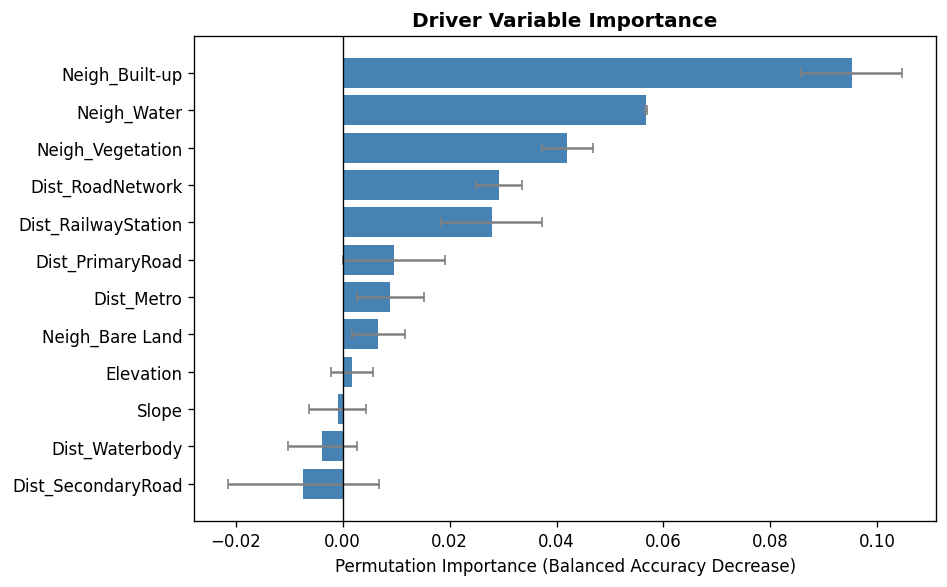

In [26]:
from sklearn.inspection import permutation_importance

# Use a subsample for speed
X_test_sc  = scaler2.transform(X_valid2[:5000])
y_test_sub = y_valid2[:5000]

print('Computing permutation importances (may take a minute)...')
perm = permutation_importance(ann2, X_test_sc, y_test_sub,
                               n_repeats=5, random_state=42,
                               scoring='balanced_accuracy')

# Feature names
driver_names = list(drivers_norm.keys())
feat_names = driver_names + [f'Neigh_{CLASS_MAP[c]}' for c in CLASS_IDS]
feat_names = feat_names[:X_test_sc.shape[1]]  # truncate if needed

importance_df = pd.DataFrame({
    'Feature': feat_names,
    'Importance Mean': perm.importances_mean,
    'Importance Std':  perm.importances_std
}).sort_values('Importance Mean', ascending=False)

print(importance_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(importance_df))
ax.barh(y_pos, importance_df['Importance Mean'], xerr=importance_df['Importance Std'],
        align='center', color='steelblue', ecolor='gray', capsize=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(importance_df['Feature'].tolist())
ax.invert_yaxis()
ax.set_xlabel('Permutation Importance (Balanced Accuracy Decrease)')
ax.set_title('Driver Variable Importance', fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('driver_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Export Results to GeoTIFF

In [27]:
def save_geotiff(array, meta, filename, nodata_val=0):
    out_meta = meta.copy()
    out_meta.update({'dtype': 'int16', 'nodata': nodata_val, 'count': 1})
    arr = array.copy().astype(np.int16)
    arr[~valid_mask] = nodata_val
    with rasterio.open(filename, 'w', **out_meta) as dst:
        dst.write(arr, 1)
    print(f'Saved: {filename}')

save_geotiff(L15_sim, meta, 'simulated_2015.tif')
save_geotiff(L35_sim, meta, 'projected_2035.tif')
save_geotiff(L45_sim, meta, 'projected_2045.tif')

# Export transition probability maps for each class
pot_2025 = predict_transition_potential(ann2, scaler2, drivers_norm, L25, valid_mask)
for i, cid in enumerate(ann2.classes_):
    if cid not in CLASS_MAP:
        continue
    out_meta = meta.copy()
    out_meta.update({'dtype': 'float32', 'nodata': -9999, 'count': 1})
    fname = f'transition_potential_{CLASS_MAP[cid].replace(" ","_")}.tif'
    prob_map = pot_2025[:, :, i].copy()
    prob_map[~valid_mask] = -9999
    with rasterio.open(fname, 'w', **out_meta) as dst:
        dst.write(prob_map, 1)
    print(f'Saved: {fname}')

Saved: simulated_2015.tif
Saved: projected_2035.tif
Saved: projected_2045.tif
Saved: transition_potential_Built-up.tif
Saved: transition_potential_Vegetation.tif
Saved: transition_potential_Water.tif
Saved: transition_potential_Bare_Land.tif


## 13. Summary Report

In [28]:
print('=' * 70)
print('BANGALORE LULC CA-ANN MODEL — SUMMARY REPORT')
print('=' * 70)
print(f'\nStudy area valid pixels : {valid_mask.sum():,}')
print(f'Pixel resolution        : {abs(meta["transform"].a):.1f} m')
print(f'Pixel area              : {PIXEL_AREA_HA:.4f} ha')
print(f'Total study area        : {valid_mask.sum() * PIXEL_AREA_HA:,.0f} ha')

print(f'\nANN Architecture        : {ann2.hidden_layer_sizes}')
print(f'ANN Iterations          : {ann2.n_iter_}')
print(f'CV Kappa (calibration)  : {np.mean(kappas):.4f} ± {np.std(kappas):.4f}')
print(f'\nCALIBRATION VALIDATION (Sim 2015 vs Obs 2015):')
print(f'  Overall Agreement     : {oa:.2f}%')
print(f'  Kappa                 : {kappa:.4f}')
print(f'  Quantity Disagreement : {total_qd:.2f}%')
print(f'  Allocation Disagreement: {total_ad:.2f}%')

print(f'\nLULC HISTORICAL CHANGE (Annual Dynamic Degree %):')
print(df_change[['DD 05-15 (%/yr)','DD 15-25 (%/yr)','DD 05-25 (%/yr)']].round(2).to_string())

print(f'\nLULC PROJECTED CHANGE (Annual Dynamic Degree %):')
print(df_dd_future.round(2).to_string())

print('\nOutputs saved:')
for f in ['simulated_2015.tif','projected_2035.tif','projected_2045.tif',
          'lulc_change_maps.png','transition_matrices.png',
          'driver_correlation.png','driver_importance.png',
          'validation_confusion_2015.png','validation_comparison_2015.png',
          'projected_lulc_2035_2045.png','lulc_timeline.png']:
    print(f'  {f}')

BANGALORE LULC CA-ANN MODEL — SUMMARY REPORT

Study area valid pixels : 4,690,224
Pixel resolution        : 30.0 m
Pixel area              : 0.0900 ha
Total study area        : 422,120 ha

ANN Architecture        : (128, 128, 64, 64, 32)
ANN Iterations          : 76
CV Kappa (calibration)  : 0.5536 ± 0.0068

CALIBRATION VALIDATION (Sim 2015 vs Obs 2015):
  Overall Agreement     : 65.67%
  Kappa                 : 0.4613
  Quantity Disagreement : 10.86%
  Allocation Disagreement: 57.79%

LULC HISTORICAL CHANGE (Annual Dynamic Degree %):
            DD 05-15 (%/yr)  DD 15-25 (%/yr)  DD 05-25 (%/yr)
Built-up               2.89             7.34             6.18
Vegetation            -0.08            -0.63            -0.35
Water                 12.34             2.73             9.22
Bare Land             -0.73            -1.80            -1.20

LULC PROJECTED CHANGE (Annual Dynamic Degree %):
            DD 25-35 (%/yr)  DD 35-45 (%/yr)  DD 25-45 (%/yr)
Built-up               5.56          